In [ ]:
#INSTALLING LIBRARIES
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")


library(sqldf)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Importing all cleaned csv files

In [ ]:
# Import cleaned datasets from GitHub

customers <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/customers_cleanData.csv"
)

orders <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/orders_cleanData.csv"
)

deliveries <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/deliveries_cleanData.csv"
)

drivers <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/drivers_cleanData.csv"
)

vehicles <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/vehicles_cleanData.csv"
)

complaints <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/complaints_cleanData.csv"
)

app_events <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/app_events_cleanData.csv"
)

hubs <- read.csv(
  "https://raw.githubusercontent.com/huzaifamohammed761-ship-it/northstar-urban-mobility-analysis/main/northstar_cleaned_dataset/hubs_cleanData.csv"
)

Dataset Inspection

In [ ]:
#overview of the dataset

dim(customers)
dim(orders)
dim(deliveries)

head(customers)
head(orders)
head(deliveries)

[1] 650  10

[1] 1250   11

[1] 950  15

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,total_complaints
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active,2
2,C0002,61,Airport,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active,0
3,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,Not Specified,Active,0
4,C0004,75,Central,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active,2
5,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active,0
6,C0006,41,West,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active,0


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,Central,East,High,151.44,Web,1


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_time_hours,risk_delivery_flag
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973,0
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,-1.100000,0
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991,0
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584,0
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814,0
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58,28.531218,0


#SQL join analysis

DELIVERY PERFORMANCE ANALYSIS

In [ ]:
# SQL join analysis

delivery_performance <- sqldf("
SELECT
    d.delivery_status,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(d.delivery_time_hours), 2) AS avg_delivery_time,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_operational_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
FROM deliveries d
GROUP BY d.delivery_status
ORDER BY avg_delivery_time DESC
")

delivery_performance

delivery_status,total_deliveries,avg_delivery_time,avg_operational_cost,avg_customer_rating
<chr>,<int>,<dbl>,<dbl>,<dbl>
Failed,132,17.78,13.15,3.06
Delayed,202,13.51,13.14,3.14
OnTime,616,6.49,12.68,4.28


The analysis shows that delayed and failed deliveries have significantly higher delivery times and operational costs . This would suggest inefficiencies in routing, dispatch management or vehice allocation.

ORDERS + CUSTOMERS JOIN

In [ ]:
# Customer order analysis

customer_order_analysis <- sqldf("
SELECT
    c.home_zone,
    COUNT(o.order_id) AS total_orders,
    ROUND(AVG(o.order_value), 2) AS avg_order_value
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
GROUP BY c.home_zone
ORDER BY total_orders DESC
")

customer_order_analysis

home_zone,total_orders,avg_order_value
<chr>,<int>,<dbl>
Central,233,88.81
North,219,87.78
East,177,94.67
West,170,91.46
South,167,91.13
Riverside,156,96.91
Airport,128,87.93


DELIVERIES + DRIVERS JOIN

In [ ]:
# Driver operational analysis

driver_analysis <- sqldf("
SELECT
    dr.driver_id,
    COUNT(de.delivery_id) AS completed_deliveries,
    ROUND(AVG(de.manual_route_override_count), 2) AS avg_route_overrides,
    ROUND(AVG(de.customer_rating_post_delivery), 2) AS avg_customer_rating
FROM drivers dr
JOIN deliveries de
ON dr.driver_id = de.driver_id
GROUP BY dr.driver_id
ORDER BY avg_customer_rating ASC
LIMIT 10
")

driver_analysis

driver_id,completed_deliveries,avg_route_overrides,avg_customer_rating
<chr>,<int>,<dbl>,<dbl>
D063,3,0.33,2.37
D111,4,0.50,2.64
D076,4,1.00,2.67
D141,9,0.78,2.93
D165,6,1.33,2.98
D021,2,2.50,3.10
D147,2,1.00,3.10
D091,6,0.17,3.13
D053,7,0.86,3.14


COMPLAINTS + DELIVERIES JOIN

In [ ]:
# Complaint and delivery analysis

complaint_analysis <- sqldf("
SELECT
    d.delivery_status,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days
FROM complaints c
JOIN deliveries d
ON c.order_id = d.order_id
GROUP BY d.delivery_status
ORDER BY total_complaints DESC
")

complaint_analysis

delivery_status,total_complaints,avg_compensation,avg_resolution_days
<chr>,<int>,<dbl>,<dbl>
OnTime,149,19.18,7.60
Delayed,48,18.36,7.63
Failed,35,25.47,9.66


VEHICLE MAINTENANCE ANALYSIS

In [ ]:
# Vehicle performance analysis

vehicle_analysis <- sqldf("
SELECT
    v.maintenance_status,
    ROUND(AVG(d.delivery_time_hours), 2) AS avg_delivery_time,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_operational_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
FROM vehicles v
JOIN deliveries d
ON v.vehicle_id = d.vehicle_id
GROUP BY v.maintenance_status
")

vehicle_analysis

maintenance_status,avg_delivery_time,avg_operational_cost,avg_customer_rating
<chr>,<dbl>,<dbl>,<dbl>
Active,8.86,12.87,3.95
InRepair,11.32,12.90,3.64
Scheduled,9.05,12.63,3.93


STATISTICAL ANALYSIS

In [ ]:
# Statistical summaries

summary(
  deliveries[
    c(
      "delivery_time_hours",
      "fuel_or_charge_cost",
      "customer_rating_post_delivery"
    )
  ]
)

 delivery_time_hours fuel_or_charge_cost customer_rating_post_delivery
 Min.   :-2.214      Min.   : 2.500      Min.   :1.000                
 1st Qu.: 2.946      1st Qu.: 9.925      1st Qu.:3.373                
 Median : 7.074      Median :12.645      Median :4.040                
 Mean   : 9.545      Mean   :12.841      Mean   :3.867                
 3rd Qu.:14.644      3rd Qu.:15.697      3rd Qu.:4.550                
 Max.   :43.457      Max.   :29.430      Max.   :5.000                
 NAs    :19                                                           

VISUALISATIONS

GRAPH FOR DELIVERY STATUS

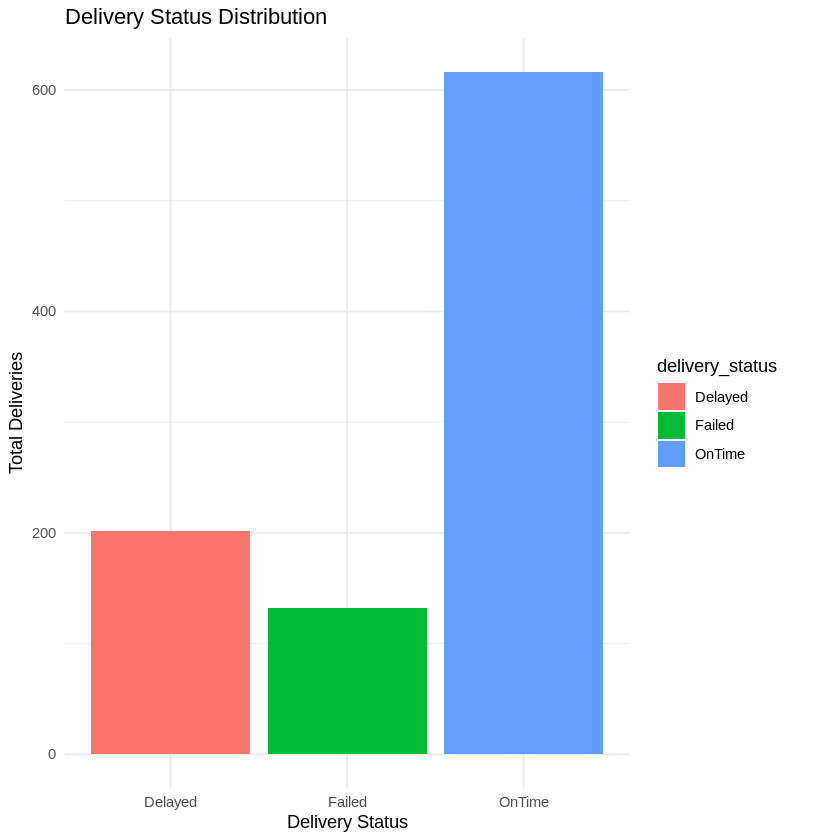

In [ ]:
ggplot(
  delivery_performance,
  aes(
    x = delivery_status,
    y = total_deliveries,
    fill = delivery_status
  )
) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Total Deliveries"
  )

GRAPH FOR ZONE ORDERS

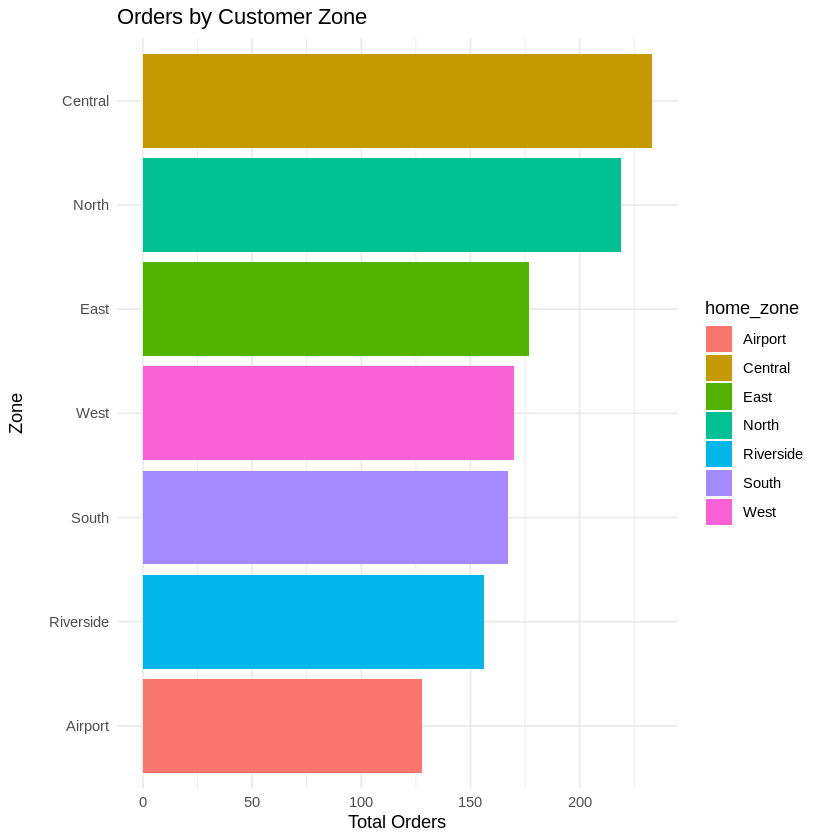

In [ ]:
ggplot(
  customer_order_analysis,
  aes(
    x = reorder(home_zone, total_orders),
    y = total_orders,
    fill = home_zone
  )
) +
  geom_bar(stat = "identity") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Orders by Customer Zone",
    x = "Zone",
    y = "Total Orders"
  )

GRAPH FOR CUSTOMER RATINGS

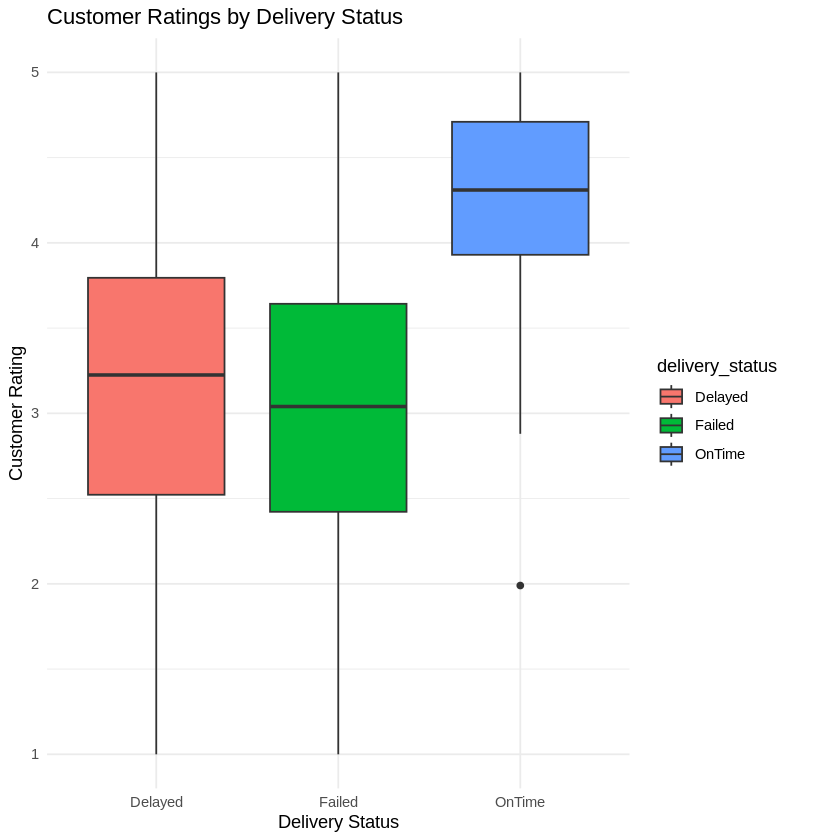

In [ ]:
ggplot(
  deliveries,
  aes(
    x = delivery_status,
    y = customer_rating_post_delivery,
    fill = delivery_status
  )
) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title = "Customer Ratings by Delivery Status",
    x = "Delivery Status",
    y = "Customer Rating"
  )

HIGH RISK DELIVERIES

In [ ]:
# Filtering high-risk deliveries

high_risk_deliveries <- sqldf("
SELECT
    delivery_id,
    delivery_status,
    manual_route_override_count,
    fuel_or_charge_cost
FROM deliveries
WHERE manual_route_override_count >= 2
AND delivery_status != 'Completed'
ORDER BY fuel_or_charge_cost DESC
")

high_risk_deliveries

delivery_id,delivery_status,manual_route_override_count,fuel_or_charge_cost
<chr>,<chr>,<int>,<dbl>
DL00897,OnTime,2,29.43
DL00144,OnTime,4,27.38
DL00119,Failed,3,25.09
DL00287,OnTime,2,24.50
DL00806,Delayed,2,24.27
DL00090,OnTime,3,24.20
DL00582,Failed,2,22.61
DL00055,Delayed,5,22.20
DL00015,OnTime,3,21.64


#CRUD OPERATIONS IN RSQL

Inserting a new record

In [ ]:
# Insert a new delivery record

sqldf("
INSERT INTO deliveries
(order_id, delivery_status, fuel_or_charge_cost)
VALUES
('ORD9001', 'Completed', 45.5)
")

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Updating a record

In [ ]:
# Update delayed delivery status

sqldf("
UPDATE deliveries
SET delivery_status = 'Completed'
WHERE order_id = 'ORD9001'
")

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Deleting a record

In [ ]:
# Delete test delivery record

sqldf("
DELETE FROM deliveries
WHERE order_id = 'ORD9001'
")

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>